In [1]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# Ex.1 NS: Stabilization (1).

We want to solve the following problem for non dimensional Navier-Stokes equations

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{1}{\rm Re}\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{i} & {\rm on} \ \Gamma_{\rm up}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on}\ \Gamma_{\rm wall}=\partial\Omega\setminus\Gamma_{\rm up}. \\
\end{cases}
\end{equation*}

In particular we want to apply Brezzi-Pitkäranta and SUPG stabilization.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

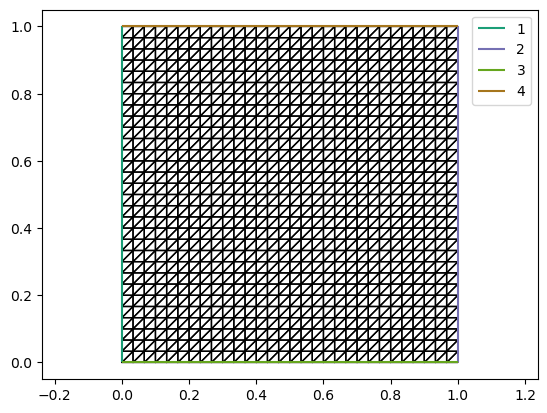

In [96]:
# Build the mesh
N = 30
mesh = UnitSquareMesh(N, N, diagonal='right')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

In [97]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 1)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Viscosity and source term
Re = 3000.0
f = Constant((0.,0.))

# Boundary conditions
x = SpatialCoordinate(mesh)
bc_up = DirichletBC(W.sub(0), Constant((1.0, 0.0)), 4)
bc_rest = DirichletBC(W.sub(0), Constant((0.0, 0.0)), [1, 2, 3])
bcs = [bc_up, bc_rest]

# Null space
nullspace = MixedVectorSpaceBasis(W, [W.sub(0),VectorSpaceBasis(constant=True, comm=COMM_WORLD)])

# Variational problem
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, delta=None, BrezziPitkaranta=False, SUPG=False):
    """
    Nonlinear iteration: solve the Navier-Stokes equations using Picard iteration.
    """
    # Fixed-point iteration
    a_fp = Constant(1.0/Re) * inner(grad(u), grad(v)) * dx + inner(dot(grad(u), u_old), v) * dx + 0.5 * div(u_old) * dot(u, v) * dx - div(v) * p * dx + q * div(u) * dx
    L_fp = dot(f, v) * dx

    # Brezzi-Pitkaranta stabilization
    if BrezziPitkaranta:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        a_fp += delta * h**2 * Re * inner(grad(p), grad(q)) * dx
    # SUPG stabilization
    elif SUPG:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        ubar = Function(FunctionSpace(mesh, "DG", 0))
        ubar.project(sqrt(dot(u_old, u_old)))
        ReK = Re * ubar * h
        one = Constant(1.0)
        deltaK = delta * conditional(lt(ReK, one), h/(ubar+1e-10), h**2 * Re)
        a_fp += deltaK * inner(- 1.0/Re * div(grad(u)) + dot(grad(u), u_old) + 0.5 * div(u_old) * u + grad(p), dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx + deltaK * div(u) * div(v) * dx
        L_fp += deltaK * inner(f, dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx
    return a_fp, L_fp

In [102]:
# Initialization: wh = 0
wh = Function(W)
uh, ph = wh.subfunctions

# ----------------------------------------------------------------------
# ATTENTION: do not use 'u_old = uh', which would yield a "shallow copy"
# ----------------------------------------------------------------------
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)

USE_SUPG = True

In [103]:
# vtk output for Paraview
basename = 'ex1'
if USE_SUPG:
    basename = basename + '_SUPG'
basename = basename + '_Re' + str(int(Re))
outfile = VTKFile("output/"+basename+"solution.pvd")
uh.rename("Velocity")
ph.rename("Pressure")
outfile.write(uh, ph)

In [104]:
# Iterative algorithm

maxit = 100
it = 0
tol = 1e-3
err = tol+1
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}

while it <= maxit and err > tol:
    it += 1

    # solve problem and compute error
    a, L = nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, delta = 0.01, BrezziPitkaranta=not USE_SUPG, SUPG=USE_SUPG)
    problem = LinearVariationalProblem(a, L, wh, bcs=bcs)
    solver =  LinearVariationalSolver(problem, solver_parameters=param, nullspace=nullspace)
    solver.solve()
    uh, ph = wh.subfunctions
    if it != 1:
        err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')
    else:
        err = float('inf')

    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfile.write(uh, ph)

    # update the old solution
    u_old.assign(uh)
    p_old.assign(ph)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: inf
--------------------------------
Step : 2
Error: 42992002.70304062
--------------------------------
Step : 3
Error: 0.5647635000159815
--------------------------------
Step : 4
Error: 0.12433731180958563
--------------------------------
Step : 5
Error: 0.04137421249675158
--------------------------------
Step : 6
Error: 0.026790996170765323
--------------------------------
Step : 7
Error: 0.009612415190177583
--------------------------------
Step : 8
Error: 0.006614799595695496
--------------------------------
Step : 9
Error: 0.0033985566745228543
--------------------------------
Step : 10
Error: 0.0029002195325517417
--------------------------------
Step : 11
Error: 0.0025721911090604926
--------------------------------
Step : 12
Error: 0.002285029581266303
--------------------------------
Step : 13
Error: 0.0020231220142373123
--------------------------------
Step : 14
Error: 0.001773558984163883
--------------------------------
St

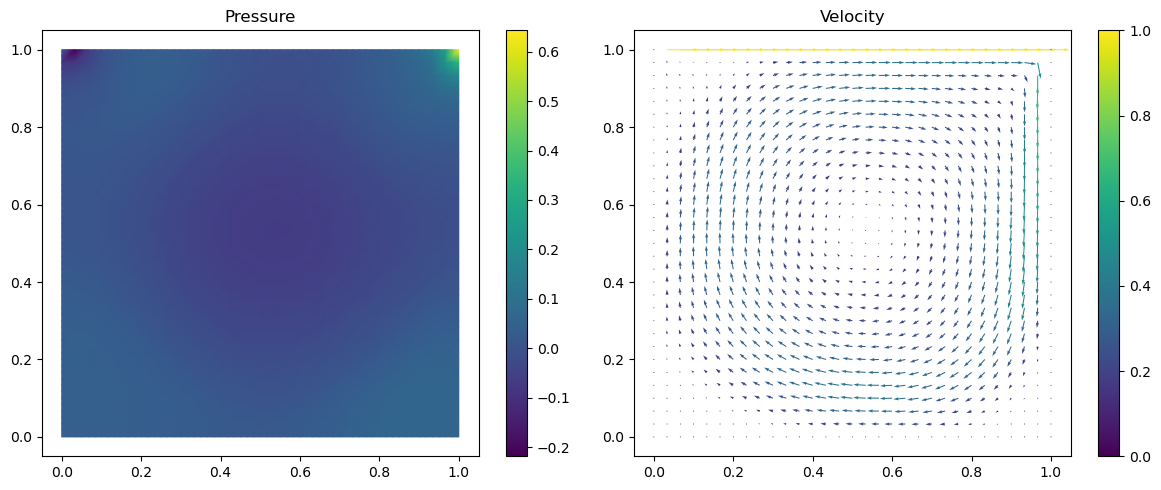

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()

# Ex.2 NS: Stabilization (2).

Now we want to solve the following problem

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{1}{\rm Re}\mathrm{div} G(\boldsymbol{u}) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = 6y(1 −y)\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, \\
\frac{1}{\rm Re} G(\boldsymbol{u})\boldsymbol{n} - p\boldsymbol{n} = 0 & {\rm on}\ \Gamma_{\rm out}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on}\ \Gamma_{\rm bottom},\\
(*) & {\rm on}\ \Gamma_{\rm top}.
\end{cases}
\end{equation*}

where $G(\boldsymbol{u}) = \nabla \boldsymbol{u}$ or $G(\boldsymbol{u}) = \varepsilon(\boldsymbol{u})$, and $(*)$ corresponds to free-slip or no-slip conditions on $\boldsymbol{u}$.



firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


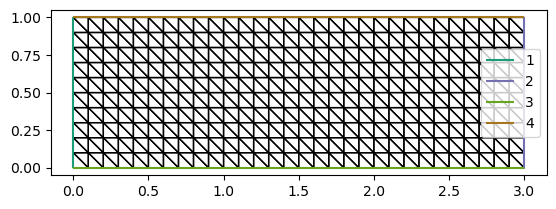

In [17]:
# Rectangle mesh

N = 10
mesh = RectangleMesh(3*N, N, 3.0, 1.0, diagonal='left')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.set_aspect("equal")

In [93]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 1)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Viscosity and source term
Re = 30.0
f = Constant((0.,0.))

# Boundary conditions
x = SpatialCoordinate(mesh)
# Inlet velocity profile: u = (6*y*(1-y), 0)
u_in = as_vector((6*x[1]*(1.0-x[1]), 0.0))
bc_in = DirichletBC(W.sub(0), u_in, 1)
# Homogeneous Neumann boundary condition on the outlet
# / 
# No slip condition on the bottom wall
bc_wall = DirichletBC(W.sub(0), Constant((0.0, 0.0)), 3)
# Free slip or no slip condition on the top wall
bc_top_noslip = DirichletBC(W.sub(0), (0.0, 0.0), 4)
bc_top_freeslip = DirichletBC(W.sub(0).sub(1), Constant(0.0), 4)
bcs_noslip = [bc_in, bc_wall, bc_top_noslip]
bcs_freeslip = [bc_in, bc_wall, bc_top_freeslip]

# Variational problem
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, symmetric = False, delta=None, BrezziPitkaranta=False, SUPG=False):
    """
    Nonlinear iteration: solve the Navier-Stokes equations using Picard iteration.
    """
    # Fixed-point iteration
    if symmetric:
        a_fp = Constant(2.0/Re) * inner(sym(grad(u)), sym(grad(v))) * dx + inner(dot(grad(u), u_old), v) * dx + 0.5 * div(u_old) * dot(u, v) * dx - div(v) * p * dx + q * div(u) * dx
        L_fp = dot(f, v) * dx
    else:
        a_fp = Constant(1.0/Re) * inner(grad(u), grad(v)) * dx + inner(dot(grad(u), u_old), v) * dx + 0.5 * div(u_old) * dot(u, v) * dx - div(v) * p * dx + q * div(u) * dx
        L_fp = dot(f, v) * dx

    # Brezzi-Pitkaranta stabilization
    if BrezziPitkaranta:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        a_fp += delta * h**2 * Re * inner(grad(p), grad(q)) * dx
    # SUPG stabilization
    elif SUPG:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        ubar = Function(FunctionSpace(mesh, "DG", 0))
        ubar.project(sqrt(dot(u_old, u_old)))
        ReK = Re * ubar * h
        one = Constant(1.0)
        deltaK = delta * conditional(lt(ReK, one), h/(ubar+1e-10), h**2 * Re)
        if symmetric:
            a_fp += deltaK * inner(- 1.0/Re * div(sym(grad(u))) + dot(grad(u), u_old) + 0.5 * div(u_old) * u + grad(p), dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx + deltaK * div(u) * div(v) * dx
        else:
            a_fp += deltaK * inner(- 1.0/Re * div(grad(u)) + dot(grad(u), u_old) + 0.5 * div(u_old) * u + grad(p), dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx + deltaK * div(u) * div(v) * dx
        L_fp += deltaK * inner(f, dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx
    return a_fp, L_fp

In [94]:
# Initialization: wh = 0
wh = Function(W)
uh, ph = wh.subfunctions

# ----------------------------------------------------------------------
# ATTENTION: do not use 'u_old = uh', which would yield a "shallow copy"
# ----------------------------------------------------------------------
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)

# Brezzi-Pitkaranta stabilization has priority over SUPG stabilization
USE_SUPG = True
USE_BREZZI_PITKARANTA = False
FREESLIP = False
SYMMETRIC = True


# vtk output for Paraview
basename = 'ex2'
if USE_SUPG:
    basename = basename + '_SUPG'
basename = basename + '_Re' + str(int(Re))
outfile = VTKFile("output/"+basename+"solution.pvd")
uh.rename("Velocity")
ph.rename("Pressure")
outfile.write(uh, ph)

# Iterative algorithm

maxit = 100
it = 0
tol = 1e-3
err = tol+1
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}

if FREESLIP:
    bcs = bcs_freeslip
else:
    bcs = bcs_noslip

while it <= maxit and err > tol:
    it += 1

    # solve problem and compute error
    a, L = nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, symmetric = SYMMETRIC, delta = 0.01, BrezziPitkaranta=USE_BREZZI_PITKARANTA, SUPG=USE_SUPG)
    problem = LinearVariationalProblem(a, L, wh, bcs=bcs)
    solver =  LinearVariationalSolver(problem, solver_parameters=param)
    solver.solve()
    uh, ph = wh.subfunctions
    if it != 1:
        err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')
    else:
        err = float('inf')

    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfile.write(uh, ph)

    # update the old solution
    u_old.assign(uh)
    p_old.assign(ph)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: inf
--------------------------------
Step : 2
Error: 1.0701991432691162
--------------------------------
Step : 3
Error: 0.00376108218513386
--------------------------------
Step : 4
Error: 0.0013897934056643485
--------------------------------
Step : 5
Error: 9.098917370748186e-05
--------------------------------
Nonlinear solver converged in 5 iterations.
--------------------------------


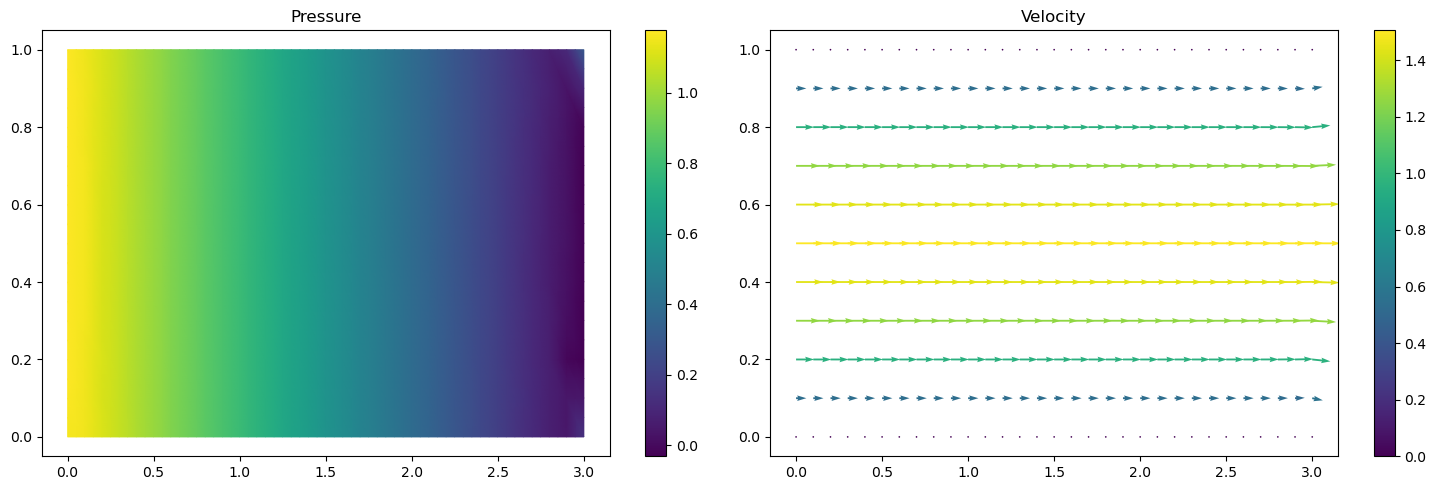

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()